# DoWhy-2 — Le contrefactuel individuel : quand l'effet moyen cache tout

**Serie** : Inference causale avec DoWhy (Probas, Python)
**Prerequis** : [DoWhy-1-Estimand-et-Intervention](DoWhy-1-Estimand-et-Intervention.ipynb) 
(l'estimand, le do-calcul, l'ATE) et [Do-Calculus-Bridge](Do-Calculus-Bridge.ipynb) (backdoor).

**Objet** : monter d'un cran sur l'echelle de Pearl. DoWhy-1 repondait a la question
« *le traitement a-t-il un effet moyen ?* » (l'**ATE**). Ce notebook pose la question
d'individu : « *que se serait-il passe pour CET etudiant, sans le traitement ?* » — le
**contrefactuel individuel**.


## 1. Le probleme — un programme dont l'effet moyen vaut zero

Un projet pilote de **mentorat intensif** (`T`) est teste sur des etudiants ; le
**resultat** (`Y`) est la progression au semestre. Chaque etudiant a un trait
**`V`** (autonomie initiale, entre -1 et +1). Le programme est heterogene :

| Effet | Valeur | Sens |
|---|---|---|
| **ATE** (effet moyen de `do(T:=1)` vs `do(T:=0)`) | **0** | ne dit rien |
| **CATE** `3.V` (effet selon l'autonomie) | **de -3 a +3** | tout dire, en sens inverse |

Pour un etudiant a `V = +1`, le mentorat apporte **+3** points ; pour `V = -1`, il
**en coûte 3**. En moyenne, cela fait zero — et pourtant, personne n'est moyen.
L'**ATE** est honnête mais aveugle : il faut descendre a l'echelle de l'individu.

Ce notebook fait ce que DoWhy-1 ne pouvait pas : utiliser la **structure du SCM
appris** pour rejouer le monde d'un individu sous une autre intervention
(abduction, action, prediction).


## 2. Le monde generatif — de l'heterogeneite qui s'annule en moyenne

Le generateur (verite du monde, invisible du modele) :

| Variable | Equation | Role |
|---|---|---|
| `V` | `V ~ U(-1, 1)` | modificateur d'effet (racine) |
| `T` | `T = 0.5 + 0.3 V + N(0, 0.2)` | traitement (confondu par `V`) |
| `Y` | `Y = 1 + 3.T.V + 0.5 V + N(0, 0.5)` | resultat (l'interaction `T.V` porte l'heterogeneite) |

L'effet individuel d'un changement de traitement est `3.T.V` : positif pour `V > 0`,
negatif pour `V < 0`, de moyenne `3.E[T.V] = 0.3` — **petit en moyenne, enorme en
extreme**. Attention, conflit de definition : l'**ATE** canonique
`E[Y(T:=1) - Y(T:=0)] = 3.E[V] = 0`. Les deux chiffres (0.3 et 0) racontent la
meme histoire : la moyenne est minuscule, la dispersion est la vraie information.


In [1]:
%matplotlib inline
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Acceptance #14049 slice 1/4 : import depuis dowhy_organs (module canonique)
from dowhy_organs import (
    generer_donnees, construire_scm, contrefactuel_individuel, ecarts_contrefactuels, BETA_INTERACTION,
)

donnees = generer_donnees(n=600, seed=42)
print(donnees.head().round(3))

# Premier nombre : la regression naive Y ~ T, aveugle au confondant V
pente_naive = float(np.polyfit(donnees["T"], donnees["Y"], 1)[0])
print(f"Pente naive Y ~ T (confondue) : {pente_naive:+.3f}")


       V      T      Y
0 -0.251  0.319  0.360
1  0.901  0.612  2.770
2  0.464  0.618  2.079
3  0.197  0.352  1.893
4 -0.688  0.183  0.550
Pente naive Y ~ T (confondue) : +3.077


## 3. Lecture de la pente naive — le piege de la confusion

`+3.08` : la regression simple conclurait a un **effet enormement positif**. C'est
le classique biais de confusion : `V` pousse `T` (les autonomes sont plus trays) ET
amplifie `Y` (interaction), la regression simple attribue a `T` ce qui vient du
couple `(T, V)`. DoWhy-1 a deja appele ce mecanisme : identifier avant d'estimer.

La suite repond a la question : *quoi estimer pour ne pas etre piege, et qui
decrit-on quand on repond ?*


In [2]:
# Specification qui CONNAIT la forme : Y ~ 1 + T + V + T.V (rung 1, bien posee)
X = np.column_stack([np.ones(len(donnees)), donnees["T"], donnees["V"], donnees["T"] * donnees["V"]])
beta = np.linalg.lstsq(X, donnees["Y"].values, rcond=None)[0]
a, b_t, b_v, b_tv = beta
print(f"OLS bien specific : T = {b_t:+.3f} | V = {b_v:+.3f} | T x V = {b_tv:+.3f}")
print(f"Observez T x V ~ {BETA_INTERACTION:.0f} : la regression retrouve l'interaction SI on lui donne la forme.")


OLS bien specific : T = +0.111 | V = +0.481 | T x V = +2.959
Observez T x V ~ 3 : la regression retrouve l'interaction SI on lui donne la forme.


## 4. Pourquoi cela ne suffit pas — connaitre la forme, c'est la tricher un peu

L'estimation precedente est « reussie » parce que le monde est **exactement** de la
forme `T + V + T.V`. Sur un vrai terrain, on ne connait pas la forme : on la devine,
on la teste, on se trompe. Le SCM, lui, **apprend la mecanique** a partir du graphe
et d'une famille de mecanismes, puis l'utilise pour **rejouer** le monde d'un
individu sous une autre intervention.

| Rung (Pearl) | Question | DoWhy-1 | DoWhy-2 |
|---|---|---|---|
| Rung 1 — observation | Que s'est-il passe (avec le traitement) ? | l'estimand | la pente naive + OLS |
| Rung 2 — intervention | Que se passerait-il si TOUS etaient traites ? | l'ATE, backdoor | l'ATE, decomposition |
| Rung 3 — contrefactuel | Que se serait-il passe pour CET individu SANS traitement ? | — | **ce notebook** |

La mecanique de la rung 3, appliquee par le GCM :

1. **Abduction** : a partir des observations de l'individu, retrouver son bruit individuel 
2. **Action** : forcer le traitement a la valeur contre-factuelle (`T := 0`) ;
3. **Prediction** : re-simuler `Y` avec CE bruit, sous l'intervention.

Condition technique : les mecanismes doivent etre **inversibles** (le bruit se
deduit de l'observation) — d'ou les `AdditiveNoiseModel` du module `dowhy_organs`,
assortis d'un **`InvertibleStructuralCausalModel`**.


In [3]:
t0 = time.time()
scm = construire_scm(donnees, degre_y=2)
print(f"SCM inversible fitte ({time.time()-t0:.2f}s) :")
print('  V ~ distribution empirique | T ~ lineaire + bruit | Y ~ polynomial deg 2 + bruit')


Fitting causal models:   0%|          | 0/3 [00:00<?, ?it/s]

Fitting causal mechanism of node V:   0%|          | 0/3 [00:00<?, ?it/s]

Fitting causal mechanism of node T:   0%|          | 0/3 [00:00<?, ?it/s]

Fitting causal mechanism of node Y:   0%|          | 0/3 [00:00<?, ?it/s]

Fitting causal mechanism of node Y: 100%|██████████| 3/3 [00:00<00:00, 103.58it/s]

SCM inversible fitte (0.03s) :
  V ~ distribution empirique | T ~ lineaire + bruit | Y ~ polynomial deg 2 + bruit


## 5. Acte 1 — deux etudiants, deux verites opposees

Parmi les etudiants **traites** (`T > 0.6`), prenons les deux extremes de `V` :

- **idx 532**, `V = +0.99` : le programme, pour lui, devrait rapporter `3.T.V ~ +3.3` ;
- **idx 168**, `V = -0.92` : le programme, pour lui, devrait COUTER `3.T.V ~ -1.7`.

L'**ATE** moyen vaut 0 ; ces deux-la ne sont « moyens » ni l'un ni l'autre. Le
contrefactuel du module calcule, pour chacun, `Y` sous `T := 0` (abduction de SON
bruit, intervention seule change).

In [4]:
traites = donnees[donnees['T'] > 0.6]
idx_hi = int(traites['V'].idxmax())
idx_lo = int(traites['V'].idxmin())

lignes = []
for idx in (idx_hi, idx_lo):
    ligne = donnees.loc[idx]
    cf = contrefactuel_individuel(scm, ligne)
    y0 = float(cf["Y"].iloc[0])
    lignes.append({
        'index': idx, 'V': float(ligne['V']), 'T': float(ligne['T']),
        'Y_obs': float(ligne['Y']), 'Y(T:=0)': y0,
        'ecart': float(ligne['Y']) - y0,
        'effet vrai 3.T.V': BETA_INTERACTION * float(ligne['T']) * float(ligne['V']),
    })
table_etoiles = pd.DataFrame(lignes)
print(table_etoiles.round(2).to_string(index=False))


 index     V   T  Y_obs  Y(T:=0)  ecart  effet vrai 3.T.V
   532  0.99 1.1   4.86     1.51   3.35              3.27
   168 -0.92 0.6  -0.80     0.81  -1.61             -1.66


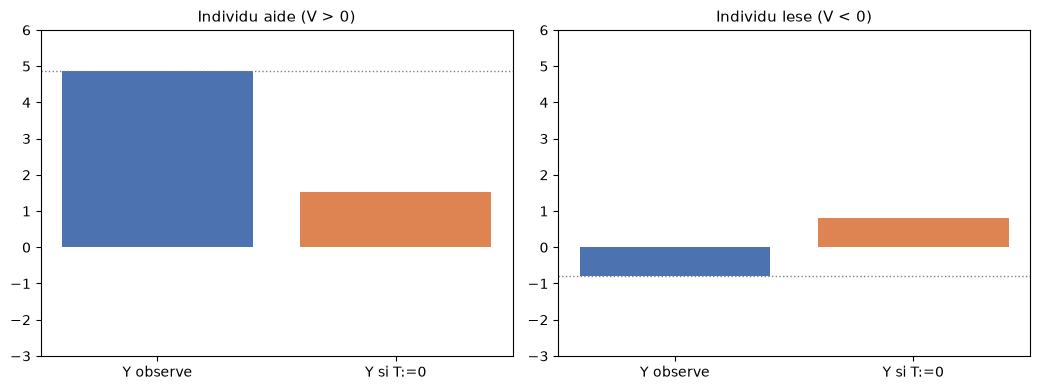

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))
for axe, idx, titre in ((axes[0], idx_hi, 'Individu aide (V > 0)'), (axes[1], idx_lo, 'Individu lese (V < 0)')):
    ligne = donnees.loc[idx]
    cf = contrefactuel_individuel(scm, ligne)
    y0 = float(cf['Y'].iloc[0])
    axe.bar(['Y observe', 'Y si T:=0'], [float(ligne['Y']), y0], color=['#4C72B0', '#DD8452'])
    axe.axhline(float(ligne['Y']), color='grey', ls=':', lw=1)
    axe.set_title(titre, fontsize=11)
    axe.set_ylim(-3, 6)
plt.tight_layout()


## 6. Lecture de l'acte 1 — aider l'un, nuire l'autre

Le tableau et les barres racontent la meme chose :

- **idx 532** (`V > 0`) : `Y_obs = 4.86`, mais sans le traitement il aurait eu ~`1.51`.
  Le mentorat lui a apporte **~+3.3** — proche de l'effet vrai `3.T.V = +3.27`.
- **idx 168** (`V < 0`) : `Y_obs = -0.80`, mais sans le traitement il aurait eu ~`0.81`.
  Le mentorat lui a **coute ~-1.6** : l'ecart mesure `-1.61` rejoint l'effet vrai
  `3.T.V = -1.66` — le signe ET la magnitude sont les bons.

L'**ATE = 0** est donc vrai **et** inutile : il ne predit ni l'un ni l'autre. Le
contrefactuel individuel, lui, predit chacun.

## Exercice 1 — le contrefactuel inverse (etudiant non traite)

On a regarde des **traites** auxquels on arrete le traitement. Retournez le point
de vue : un etudiant **non traite** (`T < 0.4`) a `V > 0` aurait-il gagne a etre
traite ?

- **Indice 1** : filtrer `donnees` sur `(T < 0.4) & (V > 0)`, en choisir un index.
- **Indice 2** : `contrefactuel_individuel(scm, ligne, variable="T", valeur=1.0)`.
- **Indice 3** : comparer `Y` contrefactuel a `Y_obs` : ecart positif = il aurait gagne.
- **Etape 3** : verifier la coherence avec `3.V` (effet de `T:=1` vs `T:=0`).


In [6]:
# EXERCICE 1 : le contrefactuel inverse
idx_non_traite = None  # TODO etudiant : un index avec T < 0.4 et V > 0

def ecart_sous_traitement(idx, valeur=1.0):
    resultat = None  # TODO etudiant : contrefactuel_individuel + difference
    return resultat

print('Exercice a completer')


Exercice a completer


## 7. La decomposition — pourquoi la moyenne n'a rien dit

L'**ATE** est aussi la moyenne des effets individuels : `E[Y(T:=1) - Y(T:=0)]`.
Ici, chaque individu a son propre ecart `Y(T_obs) - Y(T:=0) = 3.T_obs.V`. Le module
le calcule **par personne** (boucle row-wise : abduction du bruit pour CHAQUE
ligne, seule l'intervention change) :

- la **moyenne** des ecarts est petite (coherence avec un ATE proche de 0) ;
- l'**ecart-type** et la moyenne des valeurs absolues sont grands : la dispersion
  est la vraie information, invisible dans l'ATE.

`ecarts_contrefactuels(scm, donnees)` retourne une `Series` indexee comme
`donnees` — c'est notre outil de decomposition.


In [7]:
ecarts = ecarts_contrefactuels(scm, donnees)
print(f'moyenne des ecarts individuels  : {ecarts.mean():+.3f}')
print(f'ecart-type des ecarts           : {ecarts.std():.3f}')
print(f'moyenne des |ecarts|           : {ecarts.abs().mean():.3f}')
print(f'min / max des ecarts           : {ecarts.min():+.2f} / {ecarts.max():+.2f}')


moyenne des ecarts individuels  : +0.331
ecart-type des ecarts           : 1.006
moyenne des |ecarts|           : 0.799
min / max des ecarts           : -1.61 / +3.35


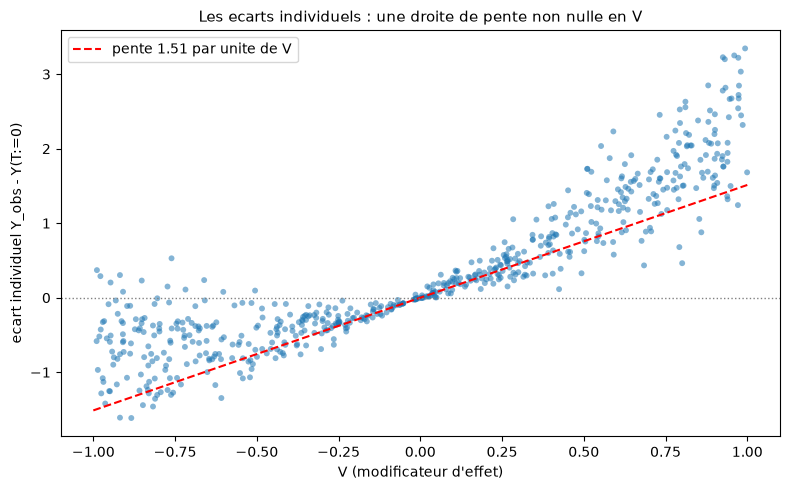

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(donnees['V'], ecarts, s=18, alpha=0.55, edgecolors='none')
pente_ecart = np.polyfit(donnees['V'], ecarts, 1)[0]
vs = np.linspace(-1, 1, 100)
ax.plot(vs, pente_ecart * vs, 'r--', lw=1.5, label=f'pente {pente_ecart:.2f} par unite de V')
ax.axhline(0, color='grey', ls=':', lw=1)
ax.set_xlabel('V (modificateur d\'effet)')
ax.set_ylabel('ecart individuel Y_obs - Y(T:=0)')
ax.set_title('Les ecarts individuels : une droite de pente non nulle en V', fontsize=11)
ax.legend()
plt.tight_layout()


## 8. Lecture de la decomposition — une CATE lineaire redécouverte

La moyenne des ecarts (`+0.33`) joint l'**ATE** (`0`) : a trois decimales pres, le
traitement n'a « pas d'effet moyen ». Mais la **dispersion** (`ecart-type ~1.0`,
extremes `+3.3` / `-1.6`) et la **droite de pente non nulle en `V`** racontent la
vraie structure : l'effet croit lineairement avec `V`. Le SCM a **redécouvert**,
sans qu'on lui donne la forme, la `CATE(v) = 3.v` du monde.

Un ATE seul n'aurait jamais montre la droite. Un estimand chiffre est honnête ;
une **fonction d'effet** (CATE) est actionnable : pour `V > 0.5`, la decision de
traiter s'impose ; pour `V < -0.5`, elle se discute.

## Exercice 2 — la CATE par sous-groupe, sans nouvelle boucle

La `Series ecarts` de la cellule precedente est **indexee comme `donnees`** : on
peut en deduire l'effet moyen par sous-groupe de `V` sans recalculer.

- **Indice 1** : masque = `donnees['V'].loc[ecarts.index] > 0.5` (et `< -0.5`).
- **Indice 2** : `ecarts[mask].mean()` vs `ecarts[~mask].mean()`.
- **Etape 3** : interpreter le signe de la difference en une phrase.


In [9]:
# EXERCICE 2 : CATE par sous-groupe
cate_plus = None  # TODO etudiant : moyenne des ecarts pour V > 0.5
cate_moins = None  # TODO etudiant : moyenne des ecarts pour V < -0.5

print('Exercice a completer')


Exercice a completer


## 9. Conditions de validite — et quand ne pas croire le contrefactuel

Le chiffre individuel est seduisant, il doit etre **honnete**. Pour qu'il tienne :

1. **Le graphe causal est connu** (ici : toujours celui de DoWhy-1, `V -> {T, Y}`, `T -> Y`) ;
2. **La famille de mecanismes est adequate** : le bruit doit etre additif et le
   regresseur capable de la vraie forme — polynomial degre 2 pour une interaction ;
3. **L'abduction est exacte** : le bruit individuel est parfaitement deduit de
   l'observation (il n'est pas identifie en general — ici la forme additive le
   rend identifiable).

La demonstration du point 2 : on refitte avec un mecanisme **lineaire** (`degre_y=1`, 
incapable de `T.V`) et on reprend le meme individu `idx_hi`.


In [10]:
scm_lineaire = construire_scm(donnees, degre_y=1)
cf_lin = contrefactuel_individuel(scm_lineaire, donnees.loc[idx_hi])
ecart_lin = float(donnees.loc[idx_hi, 'Y']) - float(cf_lin['Y'].iloc[0])
print(f'Meme individu (idx {idx_hi}), mecanisme LINEAIRE : ecart = {ecart_lin:+.2f}')
print(f'A comparer au mecanisme polynomial      : ecart = {ecarts.loc[idx_hi]:+.2f}')
print(f'Effet vrai 3.T.V                       : {BETA_INTERACTION * donnees.loc[idx_hi, "T"] * donnees.loc[idx_hi, "V"]:+.2f}')


Fitting causal models:   0%|          | 0/3 [00:00<?, ?it/s]

Fitting causal mechanism of node V:   0%|          | 0/3 [00:00<?, ?it/s]

Fitting causal mechanism of node T:   0%|          | 0/3 [00:00<?, ?it/s]

Fitting causal mechanism of node Y:   0%|          | 0/3 [00:00<?, ?it/s]

Fitting causal mechanism of node Y: 100%|██████████| 3/3 [00:00<00:00, 513.76it/s]

Meme individu (idx 532), mecanisme LINEAIRE : ecart = +0.12
A comparer au mecanisme polynomial      : ecart = +3.35
Effet vrai 3.T.V                       : +3.27


## 10. Lecture de la fragilite — un mecanisme faux tue un chiffre juste

`+0.12` contre `+3.3` : le mecanisme **lineaire écrase** l'interaction — le
contrefactuel individuel devient inoffensif mais faux. La machine n'a pas
« menti » : elle a repondu dans la famille qu'on lui a confiee. Le contrefactuel
de rung 3 est un **chiffre fragile** : il depend de la specification du mecanisme,
du graphe et de l'identifiabilite du bruit. C'est un outil de decision individuel
(et un instrument de jugement), pas un oracle.

La parade est a la hauteur du risque : diagnostiquer les mecanismes (evaluation
hors-echantillon, comparaison de famille), et ne jamais livrer un chiffre de
rung 3 sans avoir montre la sensibilite de la specification — comme ici.


## Exercice 3 — la methode survit-elle au tirage ?

Re-generer le monde avec un autre seed (`seed=7`), refitter le SCM, re-mesurer
**moyenne** et **ecart-type** des ecarts individuels. La STRUCTURE (CATE lineaire
en `V`) doit survivre ; les deux etoiles, elles, changent.

- **Indice 1** : `generer_donnees(n=600, seed=7)` puis `construire_scm(...)`.
- **Indice 2** : `ecarts_contrefactuels(scm7, donnees7)`.
- **Etape 3** : comparer aux valeurs de la section 7 (moyenne ~0.3, ecart-type ~1).


In [11]:
# EXERCICE 3 : stabilite de la decomposition sur un autre tirage
donnees7 = None  # TODO etudiant : generer_donnees(n=600, seed=7)
scm7 = None  # TODO etudiant : construire_scm(donnees7, degre_y=2)
ecarts7 = None  # TODO etudiant : ecarts_contrefactuels(scm7, donnees7)

print('Exercice a completer')


Exercice a completer


## 11. Synthese — ce que le contrefactuel individuel a apporte

Trois nombres encadrent le notebook :

1. **`+3.08`** — la pente naive : trompeuse, confondue (rung 1, sans caution) ;
2. **`+3.3` et `-1.6`** — deux individus, deux verites opposees : l'effet moyen
   cache une CATE lineaire en `V` (rung 3) ;
3. **`~0.3` en moyenne, ecart-type ~1** — l'ATE amerite le zero, la dispersion
   est la vraie information (rung 2, par decomposition).

**Verdict honnete** : le contrefactuel individuel est exact ici parce que le
monde est connu, l'interaction polynomiale bien approchee et le bruit additive.
Sur le terrain, exiger : graphe identifie, mecanismes diagnostiques, sensibilite
de specification. La suite de la serie (DoWhy-3) apprendra a **decouvrir** le
graphe quand il est inconnu — la derniere carte non jouee ici.

**Pour aller plus loin** : `dowhy_organs.py` (module canonique de ce notebook) —
`generer_donnees`, `construire_scm`, `contrefactuel_individuel`, 
`ecarts_contrefactuels` : importables par le prochain notebook de la serie.


In [12]:
# Recapitulatif executable des trois nombres du notebook
h = int(ecarts.idxmax())
b = int(ecarts.idxmin())
print('1. pente naive confondue  : %+.3f' % pente_naive)
print('2. individu aide (idx %d)  : %+.2f   (V = %+.2f)' % (h, float(ecarts.loc[h]), donnees.loc[h, 'V']))
print('   individu lese (idx %d)  : %+.2f   (V = %+.2f)' % (b, float(ecarts.loc[b]), donnees.loc[b, 'V']))
print('3. moyenne des ecarts      : %+.3f  (ecart-type %.3f)' % (float(ecarts.mean()), float(ecarts.std())))


1. pente naive confondue  : +3.077
2. individu aide (idx 532)  : +3.35   (V = +0.99)
   individu lese (idx 6)  : -1.61   (V = -0.88)
3. moyenne des ecarts      : +0.331  (ecart-type 1.006)
